![tower_bridge](tower_bridge.jpeg)

As the climate changes, predicting the weather becomes ever more important for businesses. Since the weather depends on a lot of different factors, you will want to run a lot of experiments to determine what the best approach is to predict the weather. In this project, you will run experiments for different regression models predicting the mean temperature, using a combination of `sklearn` and `MLflow`.

You will be working with data stored in `london_weather.csv`, which contains the following columns:
- **date** - recorded date of measurement - (**int**)
- **cloud_cover** - cloud cover measurement in oktas - (**float**)
- **sunshine** - sunshine measurement in hours (hrs) - (**float**)
- **global_radiation** - irradiance measurement in Watt per square meter (W/m2) - (**float**)
- **max_temp** - maximum temperature recorded in degrees Celsius (°C) - (**float**)
- **mean_temp** - mean temperature in degrees Celsius (°C) - (**float**)
- **min_temp** - minimum temperature recorded in degrees Celsius (°C) - (**float**)
- **precipitation** - precipitation measurement in millimeters (mm) - (**float**)
- **pressure** - pressure measurement in Pascals (Pa) - (**float**)
- **snow_depth** - snow depth measurement in centimeters (cm) - (**float**)

In [40]:
# Run this cell to import the modules you require
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Read in the data
weather = pd.read_csv("london_weather.csv")

print(weather)

           date  cloud_cover  sunshine  ...  precipitation  pressure  snow_depth
0      19790101          2.0       7.0  ...            0.4  101900.0         9.0
1      19790102          6.0       1.7  ...            0.0  102530.0         8.0
2      19790103          5.0       0.0  ...            0.0  102050.0         4.0
3      19790104          8.0       0.0  ...            0.0  100840.0         2.0
4      19790105          6.0       2.0  ...            0.0  102250.0         1.0
...         ...          ...       ...  ...            ...       ...         ...
15336  20201227          1.0       0.9  ...            2.0   98000.0         NaN
15337  20201228          7.0       3.7  ...            0.2   97370.0         NaN
15338  20201229          7.0       0.0  ...            0.0   98830.0         NaN
15339  20201230          6.0       0.4  ...            0.0  100200.0         NaN
15340  20201231          7.0       1.3  ...            0.0  100500.0         NaN

[15341 rows x 10 columns]


In [41]:
# Data Cleaning

weather.info()
print(weather.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       15322 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB
date                   0
cloud_cover           19
sunshine               0
global_radiation      19
max_temp               6
mean_temp             36
min_temp               2
precipitation          6
pressure               4
snow_depth          1441
dtype: int64


In [42]:
# Impute missing values
imputer = SimpleImputer(strategy="median")

weather_imputed = pd.DataFrame(
    imputer.fit_transform(weather),
    columns=weather.columns
)

print(weather_imputed.isna().sum())

date                0
cloud_cover         0
sunshine            0
global_radiation    0
max_temp            0
mean_temp           0
min_temp            0
precipitation       0
pressure            0
snow_depth          0
dtype: int64


In [43]:
# Exploratory Data Analysis

print(weather_imputed.describe())

               date   cloud_cover  ...       pressure    snow_depth
count  1.534100e+04  15341.000000  ...   15341.000000  15341.000000
mean   1.999567e+07      5.269148  ...  101536.627339      0.034418
std    1.212176e+05      2.068950  ...    1049.586598      0.519491
min    1.979010e+07      0.000000  ...   95960.000000      0.000000
25%    1.989070e+07      4.000000  ...  100920.000000      0.000000
50%    2.000010e+07      6.000000  ...  101620.000000      0.000000
75%    2.010070e+07      7.000000  ...  102240.000000      0.000000
max    2.020123e+07      9.000000  ...  104820.000000     22.000000

[8 rows x 10 columns]


count    15341.000000
mean        11.475334
std          5.722982
min         -7.600000
25%          7.100000
50%         11.400000
75%         16.000000
max         29.000000
Name: mean_temp, dtype: float64


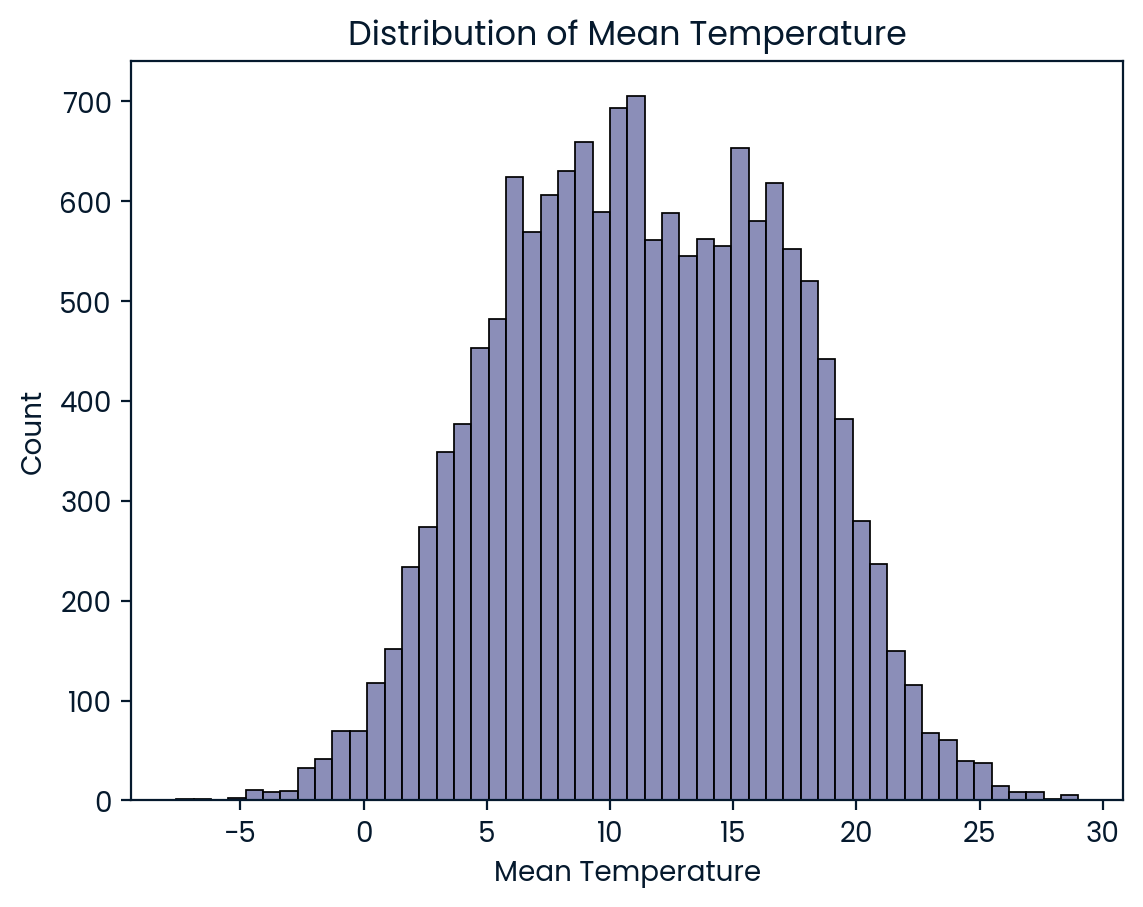

In [44]:
weather_imputed["date"] = pd.to_datetime(
    weather_imputed["date"],
    format="%Y%m%d"
)

weather_imputed["year"] = weather_imputed["date"].dt.year
weather_imputed["month"] = weather_imputed["date"].dt.month

# Exploratory Data Analysis

print(weather_imputed["mean_temp"].describe())

sns.histplot(data=weather_imputed, x="mean_temp")
plt.title("Distribution of Mean Temperature")
plt.xlabel("Mean Temperature")
plt.show()


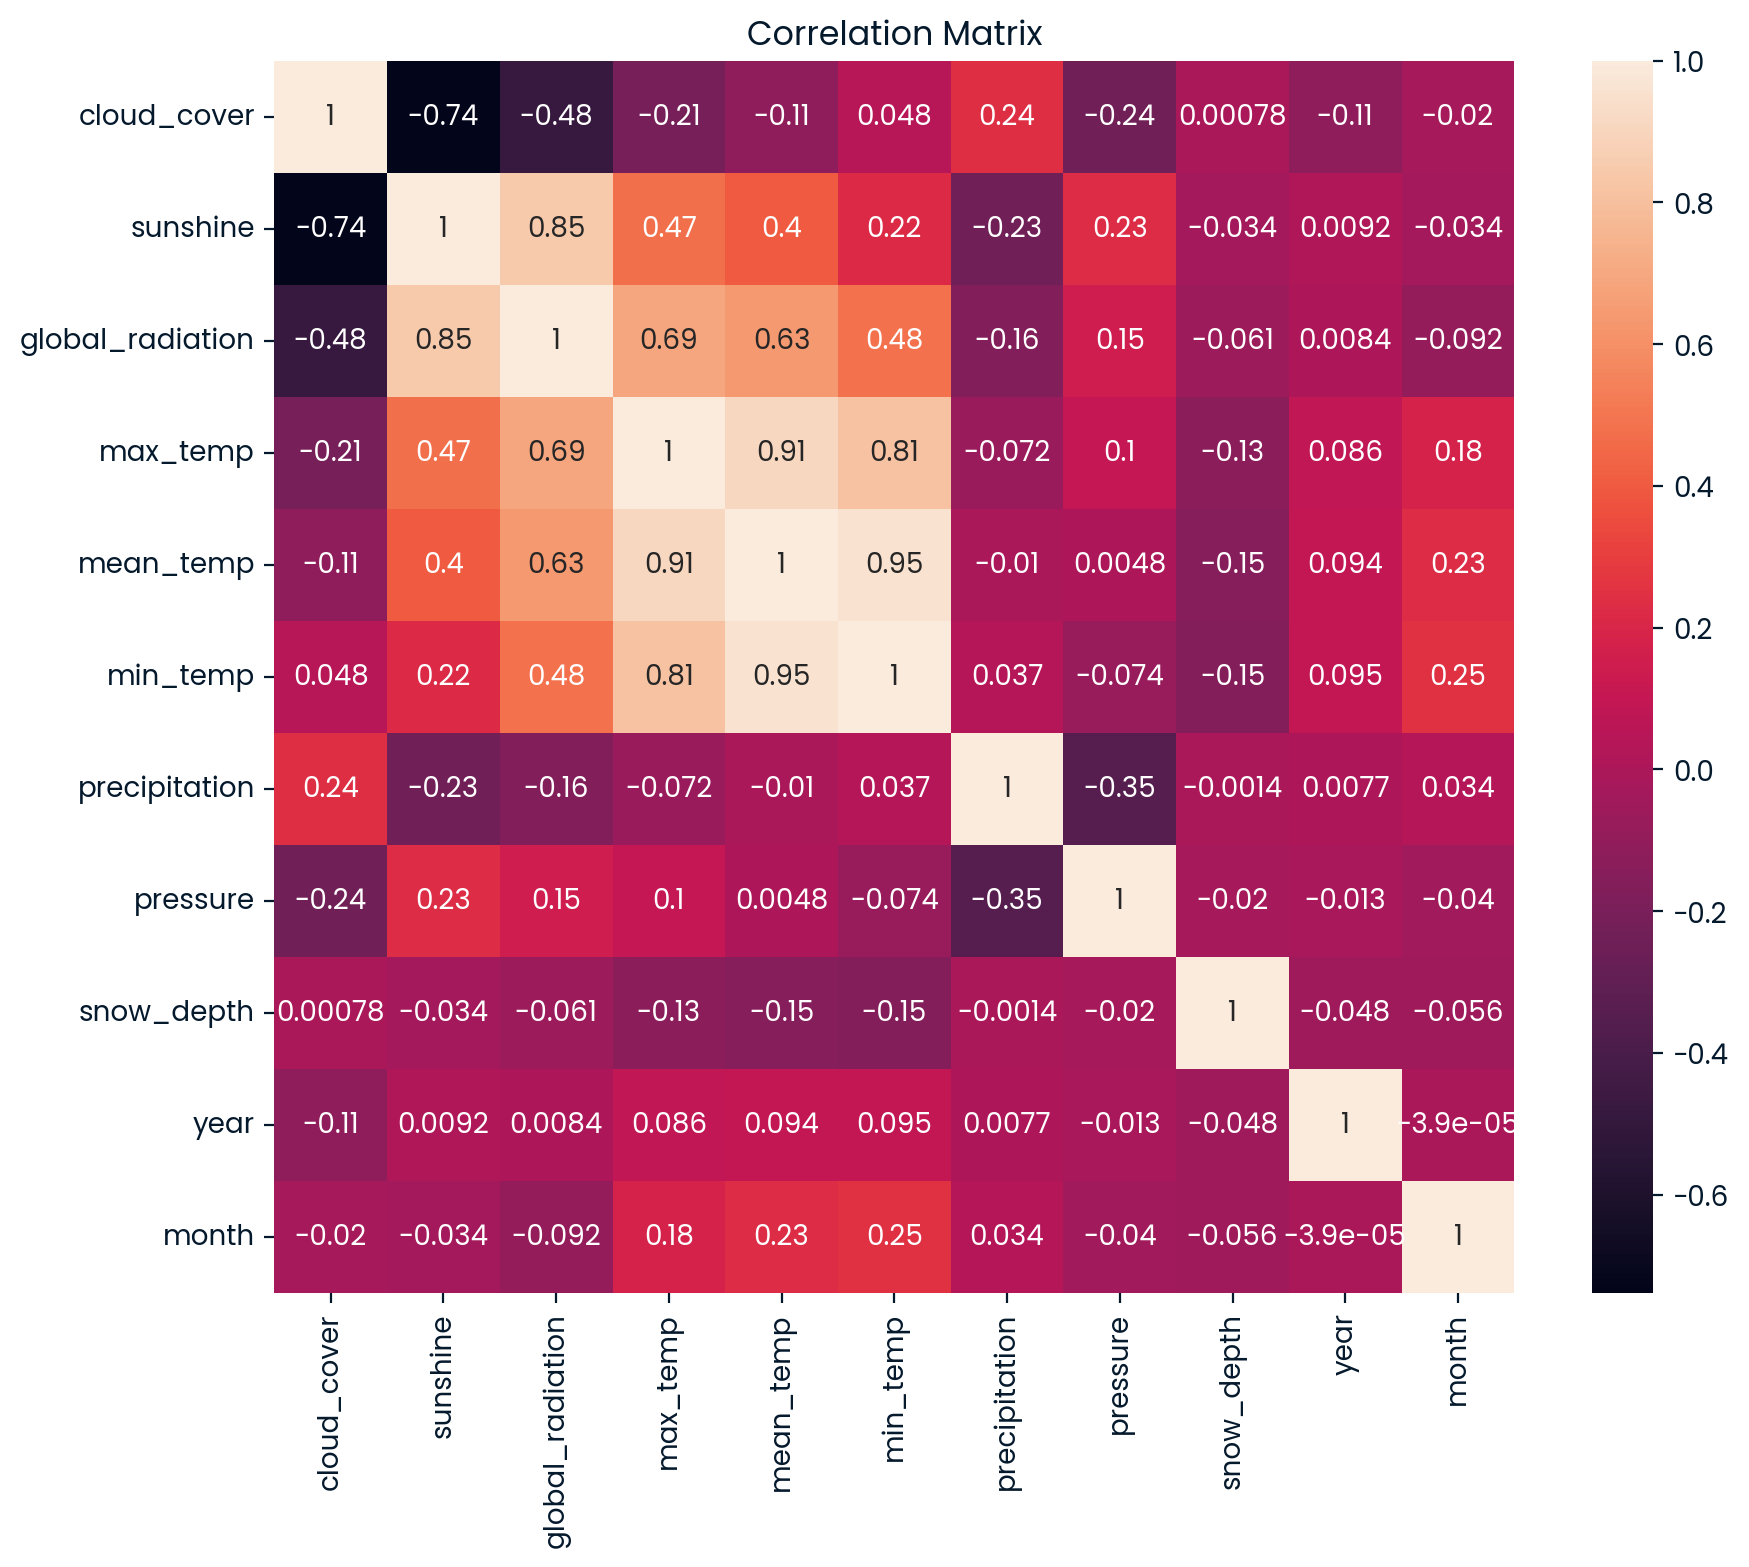

In [45]:
# Correlation Matrix

correlation = weather_imputed.drop(columns="date").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [46]:
#Feature Selection

features = [
    "min_temp",
    "max_temp",
    "global_radiation",
    "sunshine"
]

X = weather_imputed[features]
y = weather_imputed["mean_temp"]



print(X.head())
print(y.head())


   min_temp  max_temp  global_radiation  sunshine
0      -7.5       2.3              52.0       7.0
1      -7.5       1.6              27.0       1.7
2      -7.2       1.3              13.0       0.0
3      -6.5      -0.3              13.0       0.0
4      -1.4       5.6              29.0       2.0
0   -4.1
1   -2.6
2   -2.8
3   -2.6
4   -0.8
Name: mean_temp, dtype: float64


In [47]:
# Split the data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 )

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12272, 4)
(3069, 4)
(12272,)
(3069,)


In [48]:
# Linear Regression

with mlflow.start_run(run_name="linear_regression"):
    
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    
    print("Linear Regression RMSE:", rmse)
    
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_metric("rmse", rmse)
    mlflow.sklearn.log_model(lr, "model")

Linear Regression RMSE: 0.9196252244695184


In [49]:

depths = [1, 2, 10]

for idx, depth in enumerate(depths):
    run_name = f"run_{idx}"
    
    with mlflow.start_run(run_name=run_name):
        
        # Decision Tree
        model = DecisionTreeRegressor(max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f"Depth: {depth}, RMSE: {rmse}")
        
mlflow.log_param("model", "DecisionTreeRegressor")
mlflow.log_param("max_depth", depth)
mlflow.log_metric("rmse", rmse)
mlflow.sklearn.log_model(model, "model")


Depth: 10, RMSE: 1.0359653461698637


In [50]:
mlflow.end_run()
# Random Forest
depths = [1, 2, 10]

for idx, depth in enumerate(depths):
    run_name = f"run_{idx}"
    
    with mlflow.start_run(run_name=run_name):
        
        model = RandomForestRegressor(
            max_depth=depth,
            random_state=42
        )
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        rmse = mean_squared_error(y_test, y_pred, squared=False)
        
        print(f"Depth: {depth}, RMSE: {rmse}")
        
        mlflow.log_param("model", "RandomForestRegressor")
        mlflow.log_param("max_depth", depth)
        mlflow.log_metric("rmse", rmse)
        mlflow.sklearn.log_model(model, "model")
    

Depth: 1, RMSE: 3.293612882826006
Depth: 2, RMSE: 2.2595617159748964
Depth: 10, RMSE: 0.9176628941015289


In [51]:
experiment_results = mlflow.search_runs()
print(experiment_results)

                              run_id  ...                            tags.mlflow.source.name
0   7b087ea5fc934988b24b36311be17cd1  ...  /usr/lib/python3/dist-packages/python_kernel/k...
1   75eaf441e39b4ca1b99ba954696fe386  ...  /usr/lib/python3/dist-packages/python_kernel/k...
2   93316b754a7d4a87b4676aef8f45e7b7  ...  /usr/lib/python3/dist-packages/python_kernel/k...
3   d569dfa53cf247bfb44d037b21005e6e  ...  /usr/lib/python3/dist-packages/python_kernel/k...
4   994ec1da90ae42caaad9575c42406380  ...  /usr/lib/python3/dist-packages/python_kernel/k...
5   45734b9bd7f449a196453388e063aca0  ...  /usr/lib/python3/dist-packages/python_kernel/k...
6   e559c39725f94aaa99fd505d10e9ea4e  ...  /usr/lib/python3/dist-packages/python_kernel/k...
7   37d36fcaa9d64ec480ddce0c78242352  ...  /usr/lib/python3/dist-packages/python_kernel/k...
8   181a34ae311b43108dbf5d101443be78  ...  /usr/lib/python3/dist-packages/python_kernel/k...
9   8e716f48661a4442b18261ffbeef4b38  ...  /usr/lib/python3/dist-packa